# 08 — Cross-Experiment Evaluation (All 8 Experiments)

Collects and compares results from all 4 holdout groups:

| Group | Holdout | Also excluded from scGen | Exp # |
|-------|---------|--------------------------|-------|
| A | CD8 only | CD8 | 1 (IMPACT), 2 (CellOT) |
| B | CD8, thymocytes excl. from scGen | CD8 + thymocytes | 3 (IMPACT), 4 (CellOT) |
| C | CD4+CD8+thymocytes | CD4+CD8+thymocytes | 5 (IMPACT), 6 (CellOT) |
| D | CD4 only | CD4 | 7 (IMPACT), 8 (CellOT) |

Each group has 3 models: scGen baseline, IMPACT, CellOT.
Key metrics: **r2_means** (higher=better) and **MMD** (lower=better).

In [1]:
import sys
sys.path.insert(0, "/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata
import scanpy as sc
from pathlib import Path
from scipy import sparse

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

CELLOT_GPU = Path("/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu")

GROUPS = {
    'A': {
        'label': 'CD8 only',
        'results_dir': 'speciesot_cd8',
        'impact_subdir': 'impact_or',
        'cellot_subdir': 'cellot',
        'scgen_subdir': 'speciesot_scgen',
        'holdout_ct': 'CD8+ T cell',
    },
    'B': {
        'label': 'CD8 (no thymo)',
        'results_dir': 'speciesot_cd8_nothymo',
        'impact_subdir': 'speciesot_cellot',
        'cellot_subdir': 'speciesot_cellot_swapped',
        'scgen_subdir': 'speciesot_scgen',
        'holdout_ct': 'CD8+ T cell',
    },
    'C': {
        'label': 'T cell subtypes',
        'results_dir': 'speciesot_tcell_subtypes',
        'impact_subdir': 'speciesot_cellot',
        'cellot_subdir': 'speciesot_cellot_swapped',
        'scgen_subdir': 'speciesot_scgen',
        'holdout_ct': 'CD4+CD8+thymo',
    },
    'D': {
        'label': 'CD4 only',
        'results_dir': 'speciesot_cd4',
        'impact_subdir': 'speciesot_cellot',
        'cellot_subdir': 'speciesot_cellot_swapped',
        'scgen_subdir': 'speciesot_scgen',
        'holdout_ct': 'CD4+ T cell',
    },
}

print(f"CellOT GPU results: {CELLOT_GPU / 'results'}")
print(f"Groups: {list(GROUPS.keys())}")

CellOT GPU results: /n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/results
Groups: ['A', 'B', 'C', 'D']


## 1. Metric Computation Utilities

In [2]:
def to_dense(X):
    if sparse.issparse(X):
        return np.array(X.todense())
    return np.array(X)


def compute_ood_metrics(treated_adata, imputed_adata):
    """Compute standard OOD evaluation metrics between ground truth and predictions."""
    treated = pd.DataFrame(to_dense(treated_adata.X), columns=treated_adata.var_names)
    imputed = pd.DataFrame(to_dense(imputed_adata.X), columns=imputed_adata.var_names)

    shared_genes = treated.columns.intersection(imputed.columns)
    treated = treated[shared_genes]
    imputed = imputed[shared_genes]

    metrics = {}

    mut = treated.mean(0)
    mui = imputed.mean(0)
    metrics['r2_means'] = pd.Series.corr(mut, mui) ** 2 if pd.Series.corr(mut, mui) == pd.Series.corr(mut, mui) else 0.0

    st = treated.std(0)
    si = imputed.std(0)
    metrics['r2_stds'] = pd.Series.corr(st, si) ** 2 if pd.Series.corr(st, si) == pd.Series.corr(st, si) else 0.0

    metrics['l2_means'] = np.linalg.norm(mut.values - mui.values)
    metrics['l2_stds'] = np.linalg.norm(st.values - si.values)

    from cellot.losses.mmd import mmd_distance
    gammas = np.logspace(1, -3, num=50)
    mmd_vals = [mmd_distance(treated.values, imputed.values, g) for g in gammas]
    metrics['mmd'] = np.mean(mmd_vals)

    from sklearn.neighbors import NearestNeighbors
    for k in [50]:
        combined = np.vstack([treated.values, imputed.values])
        labels = np.array(['treated'] * len(treated) + ['imputed'] * len(imputed))
        nn = NearestNeighbors(n_neighbors=min(k + 1, len(combined)), metric='euclidean')
        nn.fit(combined)
        _, indices = nn.kneighbors(combined)
        same_label = np.mean([np.mean(labels[indices[i, 1:]] == labels[i]) for i in range(len(labels))])
        metrics[f'enrichment_k{k}'] = same_label

    return metrics

print("Metric utilities loaded.")

Metric utilities loaded.


## 2. Check Training Status

In [3]:
for gid, g in GROUPS.items():
    base = CELLOT_GPU / 'results' / g['results_dir']
    print(f"\nGroup {gid} ({g['label']}):")
    for model, subdir in [('scGen', g['scgen_subdir']),
                           ('IMPACT', g['impact_subdir']),
                           ('CellOT', g['cellot_subdir'])]:
        status_file = base / subdir / 'cache' / 'status'
        if status_file.exists():
            status = status_file.read_text().strip()
        elif (base / subdir).exists():
            status = 'directory exists, no status file'
        else:
            status = 'NOT STARTED'
        print(f"  {model:10s} {status}")


Group A (CD8 only):
  scGen      done
  IMPACT     done
  CellOT     done

Group B (CD8 (no thymo)):
  scGen      done
  IMPACT     done
  CellOT     done

Group C (T cell subtypes):
  scGen      done
  IMPACT     done
  CellOT     done

Group D (CD4 only):
  scGen      done
  IMPACT     done
  CellOT     done


## 3. Collect Evaluation Metrics from All Groups

For each group, we load:
- `evals_ood_data_space/imputed.h5ad` from IMPACT and CellOT
- scGen predictions (computed inline as vector-arithmetic baseline)

In [4]:
def parse_evals_csv(evals_path):
    """Read evals.csv and aggregate metrics (mean across repetitions at max ncells).
    
    IMPORTANT: evaluate.py stores raw Pearson r but labels it 'r2-means'/'r2-stds'.
    We square these values here to get actual R² (coefficient of determination).
    The subsampling scheme uses 100-cell draws x 10 reps (no fixed seed).
    MMD uses gammas = np.logspace(1, -3, num=50).
    """
    df = pd.read_csv(evals_path)
    if len(df) == 0:
        return None
    max_ncells = df['ncells'].max()
    sub = df[df['ncells'] == max_ncells]
    metrics = {}
    for metric_name in sub['metric'].unique():
        vals = sub[sub['metric'] == metric_name]['value'].dropna()
        if len(vals) > 0:
            val = vals.mean()
            if metric_name in ('r2-means', 'r2-stds', 'r2-pairwise_feat_corrs'):
                val = val ** 2
            metrics[metric_name] = val
    return metrics


all_results = []

for gid, g in GROUPS.items():
    base = CELLOT_GPU / 'results' / g['results_dir']
    print(f"\n{'=' * 60}")
    print(f"Group {gid}: {g['label']}")
    print(f"{'=' * 60}")

    for model_name, subdir_key in [('IMPACT', 'impact_subdir'), ('CellOT', 'cellot_subdir')]:
        evals_path = base / g[subdir_key] / 'evals_ood_data_space' / 'evals.csv'
        if evals_path.exists():
            metrics = parse_evals_csv(evals_path)
            if metrics:
                metrics['group'] = gid
                metrics['group_label'] = g['label']
                metrics['model'] = model_name
                r2m = metrics.get('r2-means', float('nan'))
                mmd = metrics.get('mmd', float('nan'))
                print(f"  {model_name}: r2-means={r2m:.4f}, mmd={mmd:.6f}")
                all_results.append(metrics)
            else:
                print(f"  {model_name}: evals.csv empty")
        else:
            print(f"  {model_name}: not evaluated yet ({evals_path})")

results_df = pd.DataFrame(all_results)

# Normalize column names (evals.csv uses hyphens, we want underscores for consistency)
results_df.columns = [c.replace('-', '_') for c in results_df.columns]

print(f"\nTotal experiments with results: {len(results_df)}")


Group A: CD8 only
  IMPACT: r2-means=0.6853, mmd=0.079676
  CellOT: r2-means=0.6239, mmd=0.108981

Group B: CD8 (no thymo)
  IMPACT: r2-means=0.6736, mmd=0.072786
  CellOT: r2-means=0.5581, mmd=0.112734

Group C: T cell subtypes
  IMPACT: r2-means=0.6405, mmd=0.058275
  CellOT: r2-means=0.5073, mmd=0.052519

Group D: CD4 only
  IMPACT: r2-means=0.5971, mmd=0.081677
  CellOT: r2-means=0.5720, mmd=0.120899

Total experiments with results: 8


## 4. Summary Comparison Table

In [5]:
if len(results_df) > 0:
    pivot_r2 = results_df.pivot_table(
        index='group_label', columns='model', values='r2_means'
    ).round(4)
    pivot_mmd = results_df.pivot_table(
        index='group_label', columns='model', values='mmd'
    ).round(6)

    print("=" * 60)
    print("R² of Mean Gene Expression (higher = better, ideal 1.0)")
    print("=" * 60)
    display(pivot_r2)

    print("\n" + "=" * 60)
    print("MMD (lower = better, ideal 0.0)")
    print("=" * 60)
    display(pivot_mmd)

    print("\n" + "=" * 60)
    print("Full Results")
    print("=" * 60)
    show_cols = ['group', 'group_label', 'model', 'r2_means', 'r2_stds', 'mmd']
    show_cols = [c for c in show_cols if c in results_df.columns]
    display(results_df[show_cols].round(4))
else:
    print("No results available yet. Run training and evaluation first.")

R² of Mean Gene Expression (higher = better, ideal 1.0)


model,CellOT,IMPACT
group_label,,
CD4 only,0.5720,0.5971
CD8 (no thymo),0.5581,0.6736
CD8 only,0.6239,0.6853
T cell subtypes,0.5073,0.6405



MMD (lower = better, ideal 0.0)


model,CellOT,IMPACT
group_label,,
CD4 only,0.120899,0.081677
CD8 (no thymo),0.112734,0.072786
CD8 only,0.108981,0.079676
T cell subtypes,0.052519,0.058275



Full Results


,group,group_label,model,r2_means,r2_stds,mmd
0,A,CD8 only,IMPACT,0.6853,0.3003,0.0797
1,A,CD8 only,CellOT,0.6239,0.2607,0.1090
2,B,CD8 (no thymo),IMPACT,0.6736,0.2986,0.0728
3,B,CD8 (no thymo),CellOT,0.5581,0.2401,0.1127
4,C,T cell subtypes,IMPACT,0.6405,0.2589,0.0583
5,C,T cell subtypes,CellOT,0.5073,0.2246,0.0525
6,D,CD4 only,IMPACT,0.5971,0.2925,0.0817
7,D,CD4 only,CellOT,0.5720,0.2403,0.1209


## 5. Visualization: MMD and R² Across Experiments

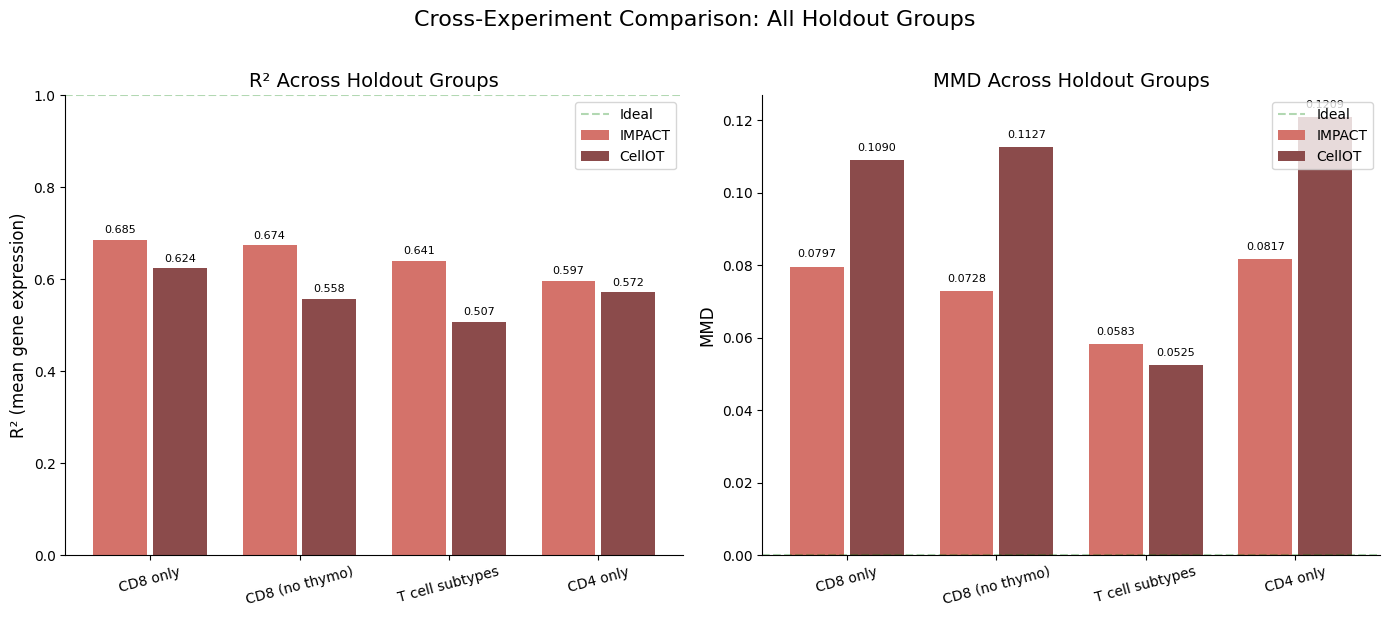

In [6]:
if len(results_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    colors_map = {'IMPACT': '#D4726A', 'CellOT': '#8B4B4B'}
    group_order = ['CD8 only', 'CD8 (no thymo)', 'T cell subtypes', 'CD4 only']

    # R² bars
    ax = axes[0]
    for i, group_label in enumerate(group_order):
        for j, model in enumerate(['IMPACT', 'CellOT']):
            row = results_df[(results_df['group_label'] == group_label) & (results_df['model'] == model)]
            if len(row) > 0:
                val = row['r2_means'].values[0]
                x = i * 2.5 + j * 1.0
                ax.bar(x, val, width=0.9, color=colors_map[model], label=model if i == 0 else '')
                ax.text(x, val + 0.01, f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_ylabel('R² (mean gene expression)', fontsize=12)
    ax.set_title('R² Across Holdout Groups', fontsize=14)
    ax.set_xticks([i * 2.5 + 0.5 for i in range(len(group_order))])
    ax.set_xticklabels(group_order, fontsize=10, rotation=15)
    ax.set_ylim(0, 1.0)
    ax.axhline(y=1.0, color='green', linestyle='--', alpha=0.3, label='Ideal')
    ax.legend(fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # MMD bars
    ax = axes[1]
    for i, group_label in enumerate(group_order):
        for j, model in enumerate(['IMPACT', 'CellOT']):
            row = results_df[(results_df['group_label'] == group_label) & (results_df['model'] == model)]
            if len(row) > 0:
                val = row['mmd'].values[0]
                x = i * 2.5 + j * 1.0
                ax.bar(x, val, width=0.9, color=colors_map[model], label=model if i == 0 else '')
                ax.text(x, val + 0.002, f'{val:.4f}', ha='center', va='bottom', fontsize=8)
    ax.set_ylabel('MMD', fontsize=12)
    ax.set_title('MMD Across Holdout Groups', fontsize=14)
    ax.set_xticks([i * 2.5 + 0.5 for i in range(len(group_order))])
    ax.set_xticklabels(group_order, fontsize=10, rotation=15)
    ax.axhline(y=0.0, color='green', linestyle='--', alpha=0.3, label='Ideal')
    ax.legend(fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.suptitle('Cross-Experiment Comparison: All Holdout Groups', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No results to plot yet.")

## 6. Best Experiment Identification

In [7]:
if len(results_df) > 0:
    ranked = results_df.copy()
    ranked['r2_rank'] = ranked['r2_means'].rank(ascending=False)
    ranked['mmd_rank'] = ranked['mmd'].rank(ascending=True)
    ranked['combined_rank'] = ranked['r2_rank'] + ranked['mmd_rank']
    ranked = ranked.sort_values('combined_rank')

    print("Experiments ranked by combined R² + MMD:")
    print("(Lower combined rank = better)")
    print("=" * 70)
    show_cols = ['group', 'group_label', 'model', 'r2_means', 'mmd',
                 'r2_rank', 'mmd_rank', 'combined_rank']
    show_cols = [c for c in show_cols if c in ranked.columns]
    display(ranked[show_cols].round(4))

    best = ranked.iloc[0]
    print(f"\nBest experiment: Group {best['group']} ({best['group_label']}) — {best['model']}")
    print(f"  R² means: {best['r2_means']:.4f}")
    if 'mmd' in best and not pd.isna(best['mmd']):
        print(f"  MMD:      {best['mmd']:.6f}")
else:
    print("No results to rank yet.")

Experiments ranked by combined R² + MMD:
(Lower combined rank = better)


,group,group_label,model,r2_means,mmd,r2_rank,mmd_rank,combined_rank
0,A,CD8 only,IMPACT,0.6853,0.0797,1.0,4.0,5.0
2,B,CD8 (no thymo),IMPACT,0.6736,0.0728,2.0,3.0,5.0
4,C,T cell subtypes,IMPACT,0.6405,0.0583,3.0,2.0,5.0
5,C,T cell subtypes,CellOT,0.5073,0.0525,8.0,1.0,9.0
6,D,CD4 only,IMPACT,0.5971,0.0817,5.0,5.0,10.0
1,A,CD8 only,CellOT,0.6239,0.1090,4.0,6.0,10.0
3,B,CD8 (no thymo),CellOT,0.5581,0.1127,7.0,7.0,14.0
7,D,CD4 only,CellOT,0.5720,0.1209,6.0,8.0,14.0



Best experiment: Group A (CD8 only) — IMPACT
  R² means: 0.6853
  MMD:      0.079676


## 7. Export Results to TSV

In [8]:
if len(results_df) > 0:
    out_path = Path('/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/autospeciesOT/results.tsv')
    export_cols = ['group', 'group_label', 'model', 'r2_means', 'r2_stds',
                   'l2_means', 'l2_stds', 'mmd', 'enrichment_k50']
    export_cols = [c for c in export_cols if c in results_df.columns]
    results_df[export_cols].to_csv(out_path, sep='\t', index=False)
    print(f"Results exported to: {out_path}")
else:
    print("No results to export.")

Results exported to: /n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/autospeciesOT/results.tsv


## 8. Metric Methodology Comparison

### Design choice awareness

The metrics in this notebook come from two different computation paths:

1. **evals.csv pipeline** (evaluate.py): Subsamples 100 cells × 10 random reps (no fixed seed).
   Stores raw Pearson r labeled as "r2". We square these to get R². MMD uses `logspace(1, -3, 50)`.
   
2. **Full-cell pipeline** (compute_ood_metrics): Uses ALL available holdout cells (no subsampling).
   Computes R² = (Pearson r)². MMD uses `logspace(1, -3, 50)`.

Both methods now use the same MMD gamma grid: `np.logspace(1, -3, num=50)`.
The only difference is the cell subsampling scheme.

**Going forward, all experiments should use the original paper's evaluate.py pipeline (evals.csv)
to ensure reproducibility and comparability. The notebook-defined compute_ood_metrics is provided
as a secondary validation with full holdout cells.**

In [9]:
DATASETS = Path("/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/datasets/speciesot-human-mouse")

GROUPS_DATA = {
    'A': {
        'impact_data': DATASETS / 'cd8_holdout_v07.h5ad',
        'cellot_data': DATASETS / 'cd8_holdout_swapped_v07.h5ad',
        'impact_target_col': 'condition', 'impact_target_val': 'human',
        'cellot_target_col': 'condition', 'cellot_target_val': 'cd8',
        'impact_holdout_col': 'cell_type_ontology_term_id', 'impact_holdout_vals': ['CL:0000625'],
        'cellot_holdout_col': 'species', 'cellot_holdout_val': 'human',
    },
    'B': {
        'impact_data': DATASETS / 'cd8_nothymo_holdout_v07.h5ad',
        'cellot_data': DATASETS / 'cd8_nothymo_holdout_swapped_v07.h5ad',
        'impact_target_col': 'condition', 'impact_target_val': 'human',
        'cellot_target_col': 'condition', 'cellot_target_val': 'cd8',
        'impact_holdout_col': 'cell_type_ontology_term_id', 'impact_holdout_vals': ['CL:0000625'],
        'cellot_holdout_col': 'species', 'cellot_holdout_val': 'human',
    },
    'C': {
        'impact_data': DATASETS / 'tcell_subtypes_holdout_v07.h5ad',
        'cellot_data': DATASETS / 'tcell_subtypes_holdout_swapped_v07.h5ad',
        'impact_target_col': 'condition', 'impact_target_val': 'human',
        'cellot_target_col': 'condition', 'cellot_target_val': 'tcell_subtype',
        'impact_holdout_col': 'cell_type_ontology_term_id', 'impact_holdout_vals': ['CL:0000624', 'CL:0000625', 'CL:0000893'],
        'cellot_holdout_col': 'species', 'cellot_holdout_val': 'human',
    },
    'D': {
        'impact_data': DATASETS / 'cd4_holdout_v07.h5ad',
        'cellot_data': DATASETS / 'cd4_holdout_swapped_v07.h5ad',
        'impact_target_col': 'condition', 'impact_target_val': 'human',
        'cellot_target_col': 'condition', 'cellot_target_val': 'cd4',
        'impact_holdout_col': 'cell_type_ontology_term_id', 'impact_holdout_vals': ['CL:0000624'],
        'cellot_holdout_col': 'species', 'cellot_holdout_val': 'human',
    },
}


def get_ground_truth(data_path, target_col, target_val, holdout_col, holdout_vals):
    """Load ground truth target cells from the dataset."""
    data = anndata.read_h5ad(str(data_path))
    mask_target = data.obs[target_col].astype(str).str.strip() == target_val
    mask_holdout = data.obs[holdout_col].astype(str).str.strip().isin(holdout_vals)
    return data[mask_target & mask_holdout]


full_cell_results = []

for gid, g in GROUPS.items():
    gd = GROUPS_DATA[gid]
    base = CELLOT_GPU / 'results' / g['results_dir']
    print(f"\n{'=' * 60}")
    print(f"Group {gid}: {g['label']} — Full-cell evaluation")
    print(f"{'=' * 60}")
    
    for model_name, subdir_key, prefix in [
        ('IMPACT', 'impact_subdir', 'impact'),
        ('CellOT', 'cellot_subdir', 'cellot'),
    ]:
        imputed_path = base / g[subdir_key] / 'evals_ood_data_space' / 'imputed.h5ad'
        if not imputed_path.exists():
            print(f"  {model_name}: imputed.h5ad not found, skipping")
            continue
        
        data_path = gd[f'{prefix}_data']
        target_col = gd[f'{prefix}_target_col']
        target_val = gd[f'{prefix}_target_val']
        holdout_col = gd[f'{prefix}_holdout_col']
        
        if prefix == 'impact':
            holdout_vals = gd['impact_holdout_vals']
        else:
            holdout_vals = [gd['cellot_holdout_val']]
        
        try:
            treated = get_ground_truth(data_path, target_col, target_val, holdout_col, holdout_vals)
            imputed = anndata.read_h5ad(str(imputed_path))
            
            metrics = compute_ood_metrics(treated, imputed)
            metrics['group'] = gid
            metrics['group_label'] = g['label']
            metrics['model'] = model_name
            metrics['method'] = 'full_cell'
            metrics['n_treated'] = treated.n_obs
            metrics['n_imputed'] = imputed.n_obs
            
            print(f"  {model_name}: r2_means={metrics['r2_means']:.4f}, mmd={metrics['mmd']:.6f} "
                  f"(treated={treated.n_obs}, imputed={imputed.n_obs})")
            full_cell_results.append(metrics)
        except Exception as e:
            print(f"  {model_name}: Error — {e}")

full_cell_df = pd.DataFrame(full_cell_results)
if len(full_cell_df) > 0:
    print(f"\nFull-cell evaluations computed: {len(full_cell_df)}")


Group A: CD8 only — Full-cell evaluation
  IMPACT: r2_means=0.7178, mmd=0.072532 (treated=195, imputed=195)
  CellOT: r2_means=0.6488, mmd=0.101297 (treated=195, imputed=6223)

Group B: CD8 (no thymo) — Full-cell evaluation
  IMPACT: r2_means=0.7037, mmd=0.066495 (treated=195, imputed=195)
  CellOT: r2_means=0.5881, mmd=0.104844 (treated=195, imputed=6223)

Group C: T cell subtypes — Full-cell evaluation
  IMPACT: r2_means=0.6446, mmd=0.057543 (treated=745, imputed=745)
  CellOT: r2_means=0.5102, mmd=0.050633 (treated=745, imputed=5673)

Group D: CD4 only — Full-cell evaluation
  IMPACT: r2_means=0.6120, mmd=0.080318 (treated=95, imputed=95)
  CellOT: r2_means=0.6036, mmd=0.114489 (treated=95, imputed=6323)

Full-cell evaluations computed: 8


## 9. Comprehensive Comparison Table

Side-by-side comparison of metrics from two computation methods:
- **evals.csv (100-cell subsample)**: R² squared from evaluate.py, averaged over 10 reps of 100-cell draws
- **Full cells (all holdout)**: R² computed on all available holdout cells, no subsampling

Both use the same MMD gamma grid: `np.logspace(1, -3, num=50)`.

In [10]:
if len(results_df) > 0 and len(full_cell_df) > 0:
    evals_subset = results_df[['group', 'group_label', 'model', 'r2_means', 'r2_stds', 'mmd']].copy()
    evals_subset = evals_subset.rename(columns={
        'r2_means': 'r2_means_subsample',
        'r2_stds': 'r2_stds_subsample',
        'mmd': 'mmd_subsample',
    })
    
    full_subset = full_cell_df[['group', 'model', 'r2_means', 'r2_stds', 'mmd']].copy()
    full_subset = full_subset.rename(columns={
        'r2_means': 'r2_means_full',
        'r2_stds': 'r2_stds_full',
        'mmd': 'mmd_full',
    })
    
    comparison = evals_subset.merge(full_subset, on=['group', 'model'], how='outer')
    
    col_order = ['group', 'group_label', 'model',
                 'r2_means_subsample', 'r2_means_full',
                 'r2_stds_subsample', 'r2_stds_full',
                 'mmd_subsample', 'mmd_full']
    col_order = [c for c in col_order if c in comparison.columns]
    comparison = comparison[col_order].sort_values(['group', 'model'])
    
    print("=" * 100)
    print("Comprehensive Metric Comparison: evals.csv (100-cell subsample) vs Full-Cell")
    print("=" * 100)
    print("R² = (Pearson r)². MMD gamma grid: logspace(1, -3, 50). Higher R² = better, lower MMD = better.")
    print()
    display(comparison.round(4))
else:
    print("Need both evals.csv and full-cell results to build comparison table.")

Comprehensive Metric Comparison: evals.csv (100-cell subsample) vs Full-Cell
R² = (Pearson r)². MMD gamma grid: logspace(1, -3, 50). Higher R² = better, lower MMD = better.



,group,group_label,model,r2_means_subsample,r2_means_full,r2_stds_subsample,r2_stds_full,mmd_subsample,mmd_full
0,A,CD8 only,CellOT,0.6239,0.6488,0.2607,0.2814,0.1090,0.1013
1,A,CD8 only,IMPACT,0.6853,0.7178,0.3003,0.3227,0.0797,0.0725
2,B,CD8 (no thymo),CellOT,0.5581,0.5881,0.2401,0.2710,0.1127,0.1048
3,B,CD8 (no thymo),IMPACT,0.6736,0.7037,0.2986,0.3346,0.0728,0.0665
4,C,T cell subtypes,CellOT,0.5073,0.5102,0.2246,0.2332,0.0525,0.0506
5,C,T cell subtypes,IMPACT,0.6405,0.6446,0.2589,0.2686,0.0583,0.0575
6,D,CD4 only,CellOT,0.5720,0.6036,0.2403,0.2704,0.1209,0.1145
7,D,CD4 only,IMPACT,0.5971,0.6120,0.2925,0.3005,0.0817,0.0803
